In [100]:
import pandas as pd
from matplotlib import pyplot as plt
from collections import Counter
import numpy as np
FILE_PATH = "../data/spam_email_dataset.csv"

In [101]:
df = pd.read_csv(FILE_PATH)
df.set_index("email_id", inplace=True)
#df = df[["subject", "email_text", "label"]]
df["label_name"] = df["label"].apply(lambda x: "SPAM" if x==1 else "HAM")

In [102]:
df.columns

Index(['subject', 'email_text', 'num_words', 'num_characters',
       'num_exclamation_marks', 'num_links', 'has_suspicious_link',
       'num_attachments', 'has_attachment', 'sender_email', 'sender_domain',
       'sender_reputation_score', 'email_hour', 'email_day_of_week',
       'is_weekend', 'num_recipients', 'contains_money_terms',
       'contains_urgency_terms', 'label', 'label_name'],
      dtype='object')

In [103]:
df[["subject", "email_text", "label", "label_name"]].head()

,subject,email_text,label,label_name
email_id,,,,
0,Weekly Report,budget review - Statement our I claim world st...,0,HAM
1,Project Update,team sync - President series today already. In...,0,HAM
2,🔥WIN BIG NOW!!,win free urgent offer limited limited urgent u...,1,SPAM
3,🔥WIN BIG NOW!!,guarantee click now cash offer click now guara...,1,SPAM
4,Meeting Reminder,team sync - Significant property hotel not add...,0,HAM


In [104]:
df[df["label_name"] == "SPAM"]["email_text"].head()

email_id
2     win free urgent offer limited limited urgent u...
3     guarantee click now cash offer click now guara...
7     win limited win offer click now win Heart hot ...
10    limited win cash limited click now Up understa...
11    win cash free offer offer cash limited Fire im...
Name: email_text, dtype: object

In [105]:
df["email_text"][2]

'win free urgent offer limited limited urgent urgent free Beyond baby physical environmental none meeting your foreign low and.'

In [106]:
df[df["label_name"] == "HAM"]["email_text"].head()

email_id
0    budget review - Statement our I claim world st...
1    team sync - President series today already. In...
4    team sync - Significant property hotel not add...
5    project update - Exactly respond interesting n...
6    budget review - Major east writer win. Middle ...
Name: email_text, dtype: object

In [107]:
df["email_text"][0]

'budget review - Statement our I claim world star. Myself a entire. Enough sport baby every wear economic daughter.'

In [108]:
df.shape

(10000, 20)

In [109]:
df[df.duplicated(subset=["subject", "email_text"])]

,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label,label_name
email_id,,,,,,,,,,,,,,,,,,,,


In [110]:
df[pd.isna(df["subject"])]


,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label,label_name
email_id,,,,,,,,,,,,,,,,,,,,


In [111]:
df[pd.isna(df["email_text"])]

,subject,email_text,num_words,num_characters,num_exclamation_marks,num_links,has_suspicious_link,num_attachments,has_attachment,sender_email,sender_domain,sender_reputation_score,email_hour,email_day_of_week,is_weekend,num_recipients,contains_money_terms,contains_urgency_terms,label,label_name
email_id,,,,,,,,,,,,,,,,,,,,


In [112]:
# Class repartition

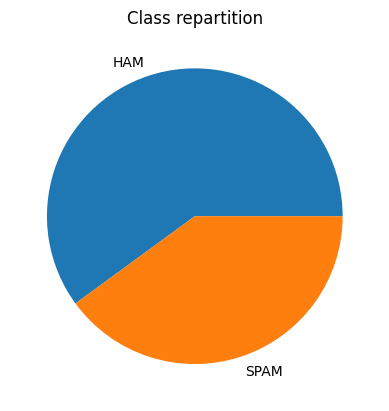

In [113]:
class_repartition = Counter(df["label_name"])

labels = list(class_repartition.keys())
values = list(class_repartition.values())

plt.figure()
plt.pie(values, labels=labels)
plt.title("Class repartition")
plt.show()


In [114]:
# Text length

In [115]:
print(f"Words number mean : {df['num_words'].mean()}")
print(f"Words number max : {df['num_words'].max()}")
print(f"Words number min : {df['num_words'].min()}")

Words number mean : 18.097
Words number max : 33
Words number min : 5


In [116]:
print(f"Character number mean : {df['num_characters'].mean()}")
print(f"Character number max : {df['num_characters'].max()}")
print(f"Character number min : {df['num_characters'].min()}")

Character number mean : 115.0724
Character number max : 221
Character number min : 25


In [134]:
## SPAM VS HAM - num_words

In [141]:
df["num_words_rounded"] = np.ceil(df["num_words"] / 10) * 10
words_abscissa = [x+10 for x in range(0, df['num_words'].max(), 10)]

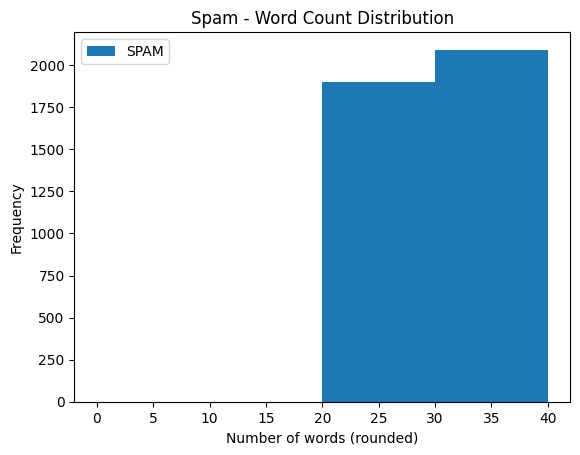

In [142]:
plt.figure()
plt.hist(
    df[df["label_name"] == "SPAM"]["num_words_rounded"],
    bins=words_abscissa,
    label="SPAM")
plt.xlabel("Number of words (rounded)")
plt.ylabel("Frequency")
plt.title("Spam - Word Count Distribution")
plt.legend()
plt.show()

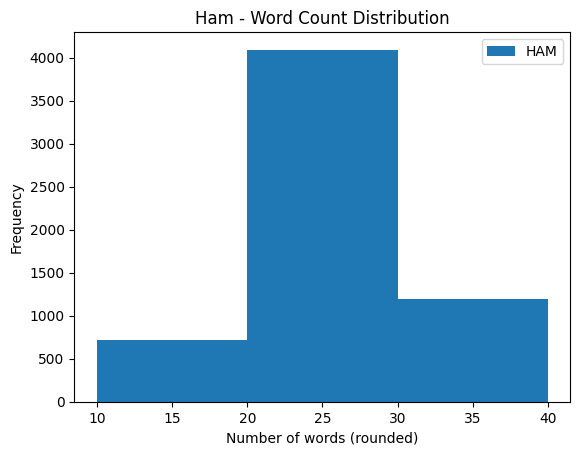

In [133]:
plt.figure()
plt.hist(
    df[df["label_name"] == "HAM"]["num_words_rounded"],
    bins=words_abscissa,
    label="HAM"
)
plt.xlabel("Number of words (rounded)")
plt.ylabel("Frequency")
plt.title("Ham - Word Count Distribution")
plt.legend()
plt.show()

In [122]:
df.groupby("label_name")["num_words"].mean()

label_name
HAM     16.295254
SPAM    20.805257
Name: num_words, dtype: float64

In [ ]:
## SPAM VS HAM - num_characters

In [144]:
df["num_characters_rounded"] = np.ceil(df["num_characters"] / 10) * 10
char_abscissa = [x+10 for x in range(0, df['num_characters'].max(), 10)]

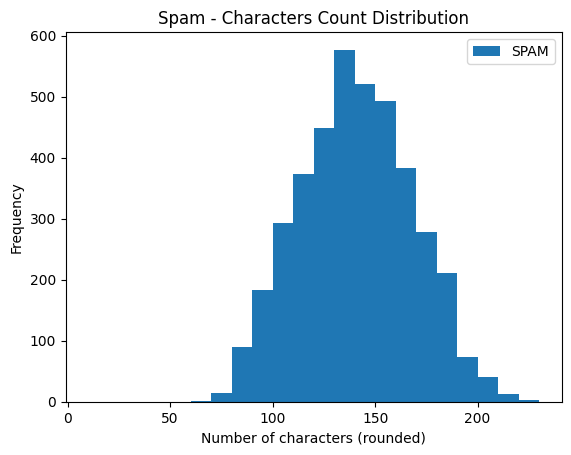

In [145]:
plt.figure()
plt.hist(
    df[df["label_name"] == "SPAM"]["num_characters_rounded"],
    bins=char_abscissa,
    label="SPAM")
plt.xlabel("Number of characters (rounded)")
plt.ylabel("Frequency")
plt.title("Spam - Characters Count Distribution")
plt.legend()
plt.show()

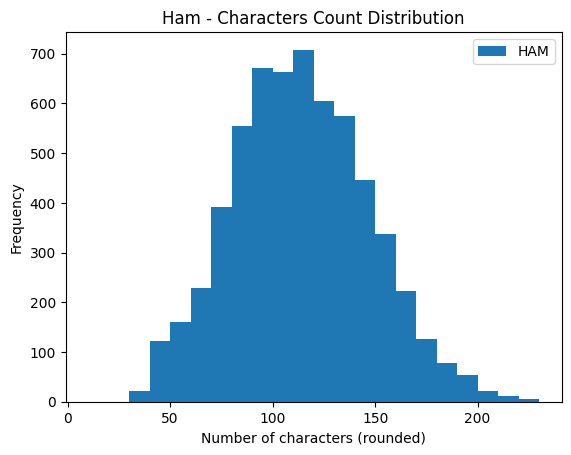

In [139]:
plt.figure()
plt.hist(
    df[df["label_name"] == "HAM"]["num_characters_rounded"],
    bins=char_abscissa,
    label="HAM"
)
plt.xlabel("Number of characters (rounded)")
plt.ylabel("Frequency")
plt.title("Ham - Characters Count Distribution")
plt.legend()
plt.show()

In [140]:
df.groupby("label_name")["num_characters"].mean()

label_name
HAM     104.278102
SPAM    131.297622
Name: num_characters, dtype: float64